"""
Reliability Study Summary Analysis

This notebook generates summary visualizations from:
- cross_split_metrics.csv (Dice, Jaccard, relative_diff per model/subject)
- image_quality_metrics.csv (SNR, CNR per subject)

Run each cell in order in your Jupyter notebook.
"""



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
reliability_df = pd.read_csv("cross_split_metrics.csv")
quality_df = pd.read_csv("image_quality_metrics.csv")

print(
    f"Reliability data: {len(reliability_df)} rows, {reliability_df['subject_id'].nunique()} subjects"
)
print(f"Quality data: {len(quality_df)} subjects")
print(f"\nModels in reliability data: {reliability_df['model'].unique().tolist()}")

Reliability data: 414 rows, 23 subjects
Quality data: 23 subjects

Models in reliability data: ['SP Model - Cortical Plate', 'SP Model - Subplate', '5-Label Model - Cortical Plate']


In [4]:
def print_summary_statistics(df):
    """Print summary statistics for reliability metrics by model."""
    print("\n" + "=" * 80)
    print("RELIABILITY METRICS SUMMARY BY MODEL")
    print("=" * 80)

    summary = (
        df.groupby("model")
        .agg(
            {
                "dice": ["mean", "std", "min", "max", "count"],
                "jaccard": ["mean", "std"],
                "relative_diff": ["mean", "std"],
            }
        )
        .round(4)
    )

    for model in df["model"].unique():
        model_data = df[df["model"] == model]
        n_subjects = model_data["subject_id"].nunique()
        n_comparisons = len(model_data)

        print(f"\n{model}")
        print(f"  Subjects: {n_subjects}, Pairwise comparisons: {n_comparisons}")
        print(
            f"  Dice:         {model_data['dice'].mean():.4f} ± {model_data['dice'].std():.4f}  (range: {model_data['dice'].min():.3f} - {model_data['dice'].max():.3f})"
        )
        print(
            f"  Jaccard:      {model_data['jaccard'].mean():.4f} ± {model_data['jaccard'].std():.4f}"
        )
        print(
            f"  Rel. Diff %:  {model_data['relative_diff'].mean():.2f} ± {model_data['relative_diff'].std():.2f}"
        )


print_summary_statistics(reliability_df)


RELIABILITY METRICS SUMMARY BY MODEL

SP Model - Cortical Plate
  Subjects: 23, Pairwise comparisons: 138
  Dice:         0.8101 ± 0.0869  (range: 0.453 - 0.922)
  Jaccard:      0.6889 ± 0.1130
  Rel. Diff %:  2.06 ± 1.49

SP Model - Subplate
  Subjects: 23, Pairwise comparisons: 138
  Dice:         0.8533 ± 0.0621  (range: 0.597 - 0.943)
  Jaccard:      0.7489 ± 0.0889
  Rel. Diff %:  1.50 ± 1.28

5-Label Model - Cortical Plate
  Subjects: 23, Pairwise comparisons: 138
  Dice:         0.7864 ± 0.0932  (range: 0.427 - 0.915)
  Jaccard:      0.6569 ± 0.1182
  Rel. Diff %:  2.70 ± 2.07


/tmp/ipykernel_2435798/1244267261.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_labels, patch_artist=True, widths=0.6)


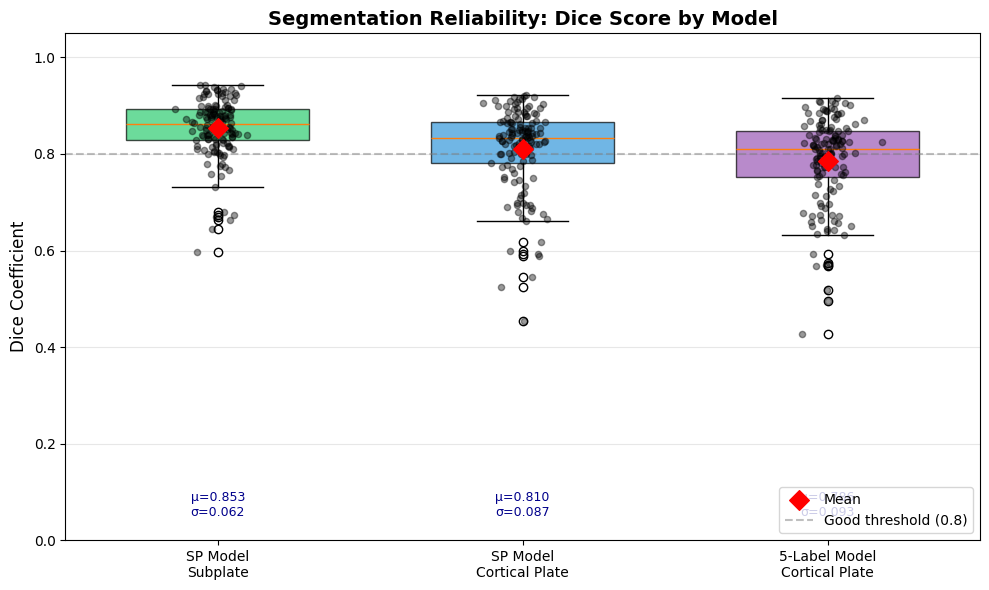

In [5]:
def plot_dice_by_model(df):
    """Box plot comparing Dice scores across models."""
    fig, ax = plt.subplots(figsize=(10, 6))

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]
    model_labels = [
        "SP Model\nSubplate",
        "SP Model\nCortical Plate",
        "5-Label Model\nCortical Plate",
    ]
    colors = ["#2ecc71", "#3498db", "#9b59b6"]

    data = [df[df["model"] == m]["dice"].values for m in models]

    bp = ax.boxplot(data, labels=model_labels, patch_artist=True, widths=0.6)

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Add individual points
    for i, d in enumerate(data):
        x = np.random.normal(i + 1, 0.04, size=len(d))
        ax.scatter(x, d, alpha=0.4, s=20, color="black", zorder=3)

    # Add mean markers
    means = [np.mean(d) for d in data]
    ax.scatter(
        range(1, len(models) + 1),
        means,
        color="red",
        s=100,
        zorder=5,
        marker="D",
        label="Mean",
    )

    ax.set_ylabel("Dice Coefficient", fontsize=12)
    ax.set_title(
        "Segmentation Reliability: Dice Score by Model", fontsize=14, fontweight="bold"
    )
    ax.set_ylim(0, 1.05)
    ax.axhline(
        y=0.8, color="gray", linestyle="--", alpha=0.5, label="Good threshold (0.8)"
    )
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3, axis="y")

    # Add stats annotation
    for i, (m, d) in enumerate(zip(means, data)):
        ax.annotate(
            f"μ={m:.3f}\nσ={np.std(d):.3f}",
            xy=(i + 1, 0.05),
            ha="center",
            fontsize=9,
            color="darkblue",
        )

    plt.tight_layout()
    return fig


fig = plot_dice_by_model(reliability_df)
plt.show()

/tmp/ipykernel_2435798/638424927.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_labels, patch_artist=True, widths=0.6)


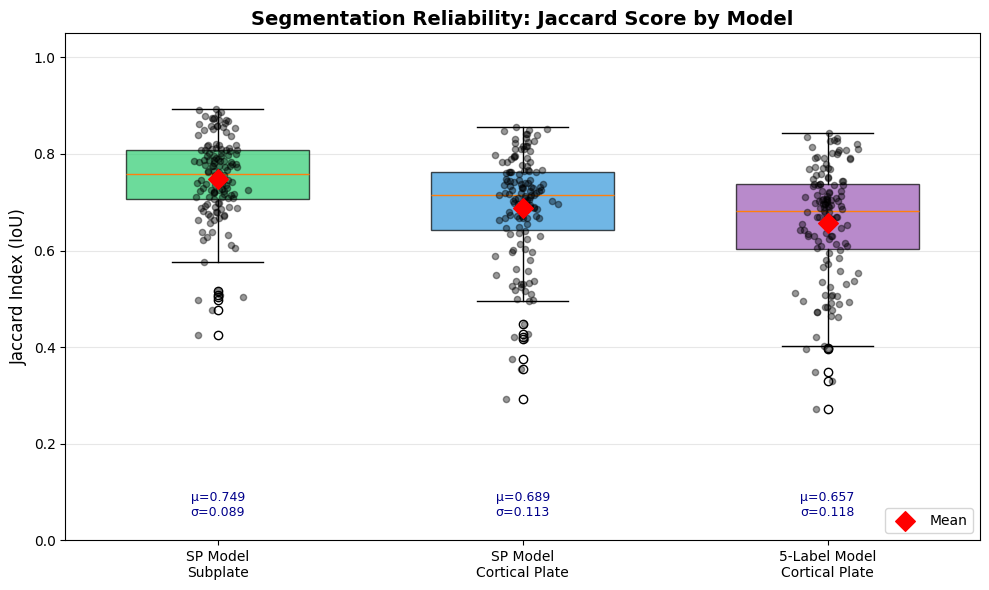

In [6]:
def plot_jaccard_by_model(df):
    """Box plot comparing Jaccard scores across models."""
    fig, ax = plt.subplots(figsize=(10, 6))

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]
    model_labels = [
        "SP Model\nSubplate",
        "SP Model\nCortical Plate",
        "5-Label Model\nCortical Plate",
    ]
    colors = ["#2ecc71", "#3498db", "#9b59b6"]

    data = [df[df["model"] == m]["jaccard"].values for m in models]

    bp = ax.boxplot(data, labels=model_labels, patch_artist=True, widths=0.6)

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, d in enumerate(data):
        x = np.random.normal(i + 1, 0.04, size=len(d))
        ax.scatter(x, d, alpha=0.4, s=20, color="black", zorder=3)

    means = [np.mean(d) for d in data]
    ax.scatter(
        range(1, len(models) + 1),
        means,
        color="red",
        s=100,
        zorder=5,
        marker="D",
        label="Mean",
    )

    ax.set_ylabel("Jaccard Index (IoU)", fontsize=12)
    ax.set_title(
        "Segmentation Reliability: Jaccard Score by Model",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3, axis="y")

    for i, (m, d) in enumerate(zip(means, data)):
        ax.annotate(
            f"μ={m:.3f}\nσ={np.std(d):.3f}",
            xy=(i + 1, 0.05),
            ha="center",
            fontsize=9,
            color="darkblue",
        )

    plt.tight_layout()
    return fig


fig = plot_jaccard_by_model(reliability_df)
plt.show()

/tmp/ipykernel_2435798/3999800110.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_labels, patch_artist=True, widths=0.6)


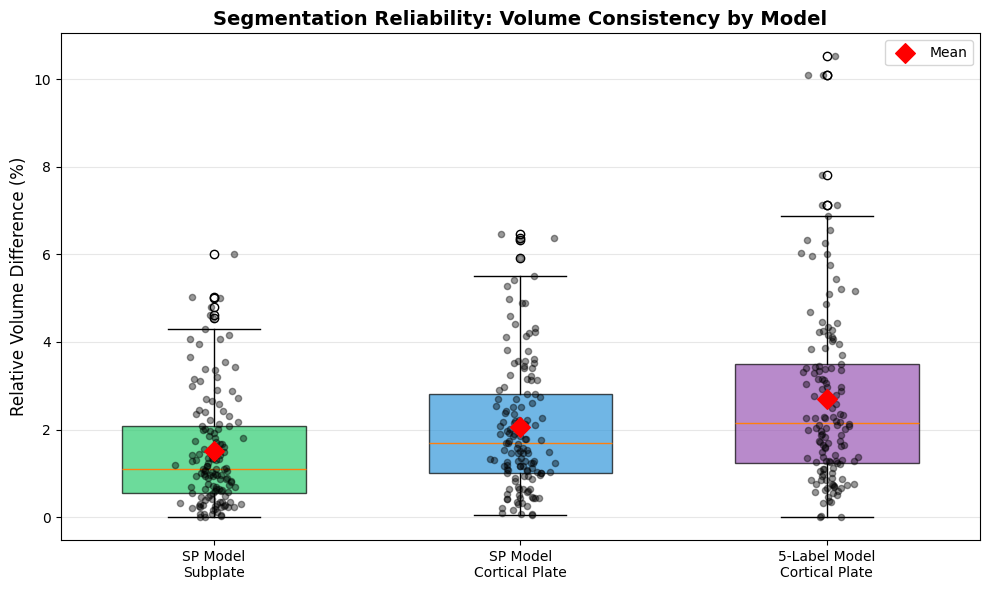

In [7]:
def plot_relative_diff_by_model(df):
    """Box plot comparing relative volume difference across models."""
    fig, ax = plt.subplots(figsize=(10, 6))

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]
    model_labels = [
        "SP Model\nSubplate",
        "SP Model\nCortical Plate",
        "5-Label Model\nCortical Plate",
    ]
    colors = ["#2ecc71", "#3498db", "#9b59b6"]

    data = [df[df["model"] == m]["relative_diff"].values for m in models]

    bp = ax.boxplot(data, labels=model_labels, patch_artist=True, widths=0.6)

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, d in enumerate(data):
        x = np.random.normal(i + 1, 0.04, size=len(d))
        ax.scatter(x, d, alpha=0.4, s=20, color="black", zorder=3)

    means = [np.mean(d) for d in data]
    ax.scatter(
        range(1, len(models) + 1),
        means,
        color="red",
        s=100,
        zorder=5,
        marker="D",
        label="Mean",
    )

    ax.set_ylabel("Relative Volume Difference (%)", fontsize=12)
    ax.set_title(
        "Segmentation Reliability: Volume Consistency by Model",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    return fig


fig = plot_relative_diff_by_model(reliability_df)
plt.show()

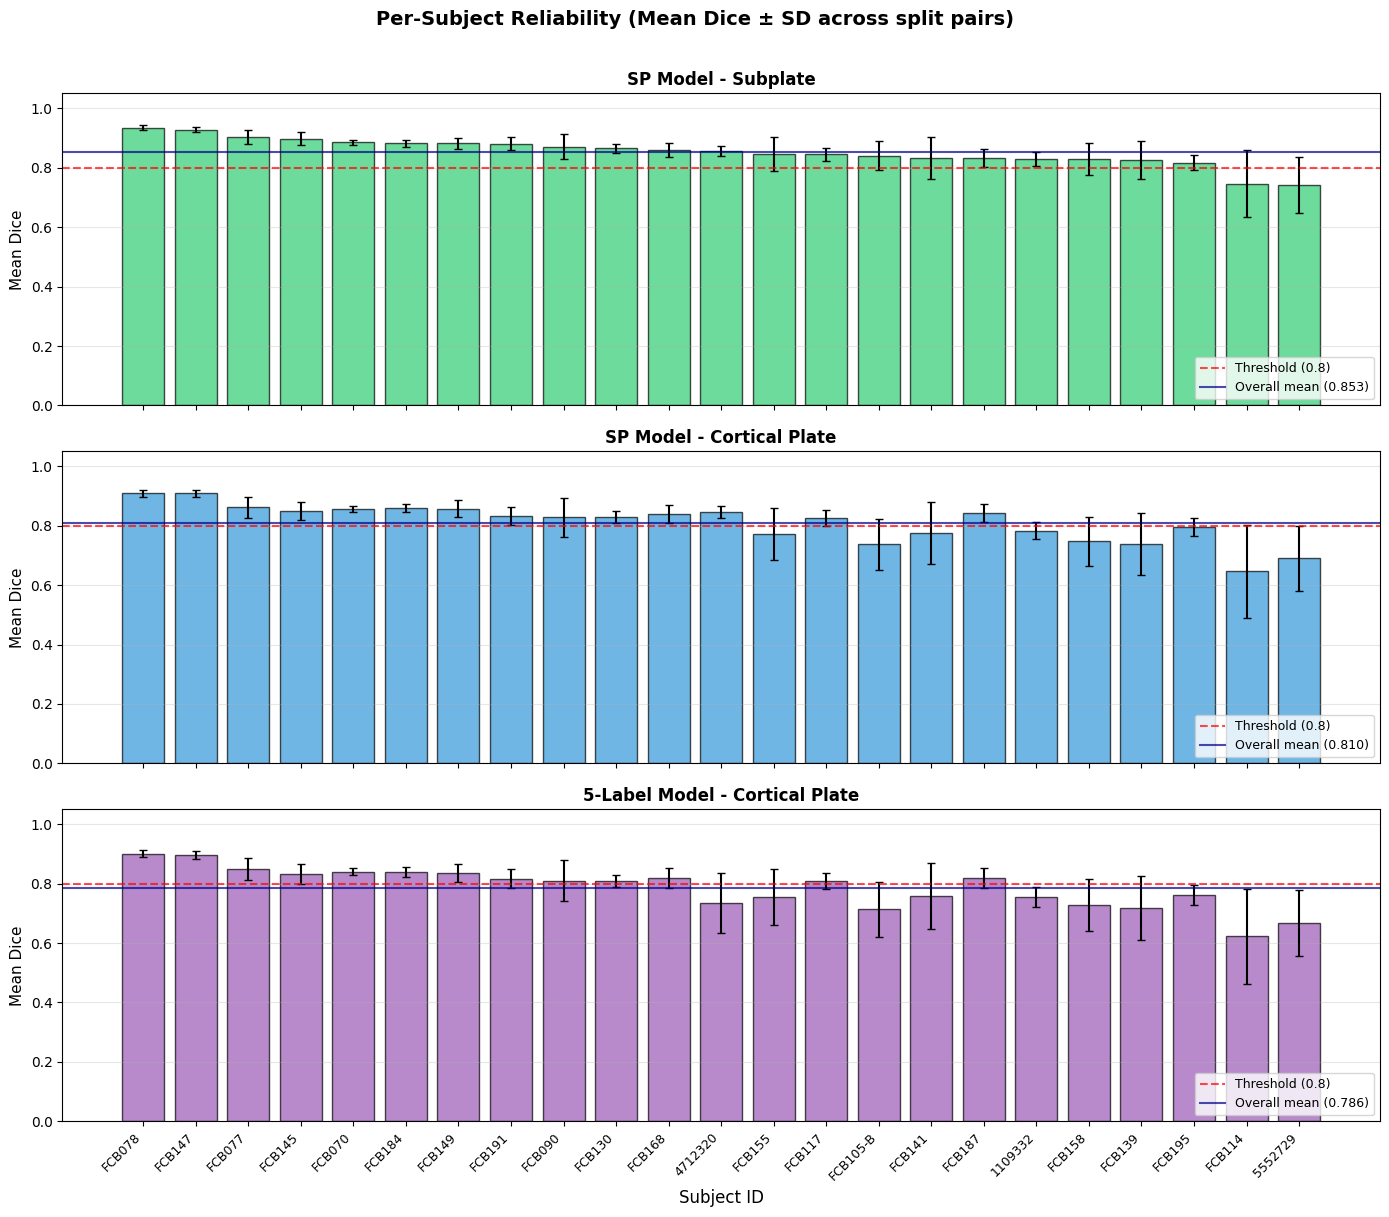

In [8]:
def plot_per_subject_dice(df):
    """Bar plot showing mean Dice per subject, colored by model."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]
    colors = ["#2ecc71", "#3498db", "#9b59b6"]

    # Get subject order (sorted by SP Subplate mean dice)
    sp_subplate = df[df["model"] == "SP Model - Subplate"]
    subject_means = (
        sp_subplate.groupby("subject_id")["dice"].mean().sort_values(ascending=False)
    )
    subject_order = subject_means.index.tolist()

    for ax, model, color in zip(axes, models, colors):
        model_df = df[df["model"] == model]
        subject_stats = (
            model_df.groupby("subject_id")["dice"]
            .agg(["mean", "std"])
            .reindex(subject_order)
        )

        x = np.arange(len(subject_order))
        bars = ax.bar(
            x,
            subject_stats["mean"],
            yerr=subject_stats["std"],
            capsize=3,
            color=color,
            alpha=0.7,
            edgecolor="black",
        )

        ax.axhline(
            y=0.8, color="red", linestyle="--", alpha=0.7, label="Threshold (0.8)"
        )
        ax.axhline(
            y=subject_stats["mean"].mean(),
            color="darkblue",
            linestyle="-",
            alpha=0.7,
            label=f'Overall mean ({subject_stats["mean"].mean():.3f})',
        )

        ax.set_ylabel("Mean Dice", fontsize=11)
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.legend(loc="lower right", fontsize=9)
        ax.grid(True, alpha=0.3, axis="y")

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(subject_order, rotation=45, ha="right", fontsize=9)
    axes[-1].set_xlabel("Subject ID", fontsize=12)

    plt.suptitle(
        "Per-Subject Reliability (Mean Dice ± SD across split pairs)",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    return fig


fig = plot_per_subject_dice(reliability_df)
plt.show()

In [9]:
def statistical_model_comparison(df):
    """Perform statistical tests comparing models."""
    print("\n" + "=" * 80)
    print("STATISTICAL COMPARISON BETWEEN MODELS")
    print("=" * 80)

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]

    # Pairwise comparisons
    comparisons = [
        ("SP Model - Subplate", "SP Model - Cortical Plate"),
        ("SP Model - Subplate", "5-Label Model - Cortical Plate"),
        ("SP Model - Cortical Plate", "5-Label Model - Cortical Plate"),
    ]

    print("\nPairwise Wilcoxon signed-rank tests on Dice scores:")
    print("-" * 60)

    for model_a, model_b in comparisons:
        # Get matched pairs by subject
        df_a = df[df["model"] == model_a].groupby("subject_id")["dice"].mean()
        df_b = df[df["model"] == model_b].groupby("subject_id")["dice"].mean()

        # Align subjects
        common_subjects = df_a.index.intersection(df_b.index)
        data_a = df_a.loc[common_subjects].values
        data_b = df_b.loc[common_subjects].values

        # Wilcoxon test (paired, non-parametric)
        stat, p_value = stats.wilcoxon(data_a, data_b)

        # Effect size (mean difference)
        mean_diff = np.mean(data_a) - np.mean(data_b)

        significance = (
            "***"
            if p_value < 0.001
            else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        )

        print(f"\n{model_a[:20]:20s} vs {model_b[:20]:20s}")
        print(f"  Mean difference: {mean_diff:+.4f}")
        print(f"  Wilcoxon stat: {stat:.1f}, p-value: {p_value:.4f} {significance}")
        print(f"  N subjects: {len(common_subjects)}")


statistical_model_comparison(reliability_df)


STATISTICAL COMPARISON BETWEEN MODELS

Pairwise Wilcoxon signed-rank tests on Dice scores:
------------------------------------------------------------

SP Model - Subplate  vs SP Model - Cortical 
  Mean difference: +0.0433
  Wilcoxon stat: 2.0, p-value: 0.0000 ***
  N subjects: 23

SP Model - Subplate  vs 5-Label Model - Cort
  Mean difference: +0.0669
  Wilcoxon stat: 0.0, p-value: 0.0000 ***
  N subjects: 23

SP Model - Cortical  vs 5-Label Model - Cort
  Mean difference: +0.0237
  Wilcoxon stat: 0.0, p-value: 0.0000 ***
  N subjects: 23


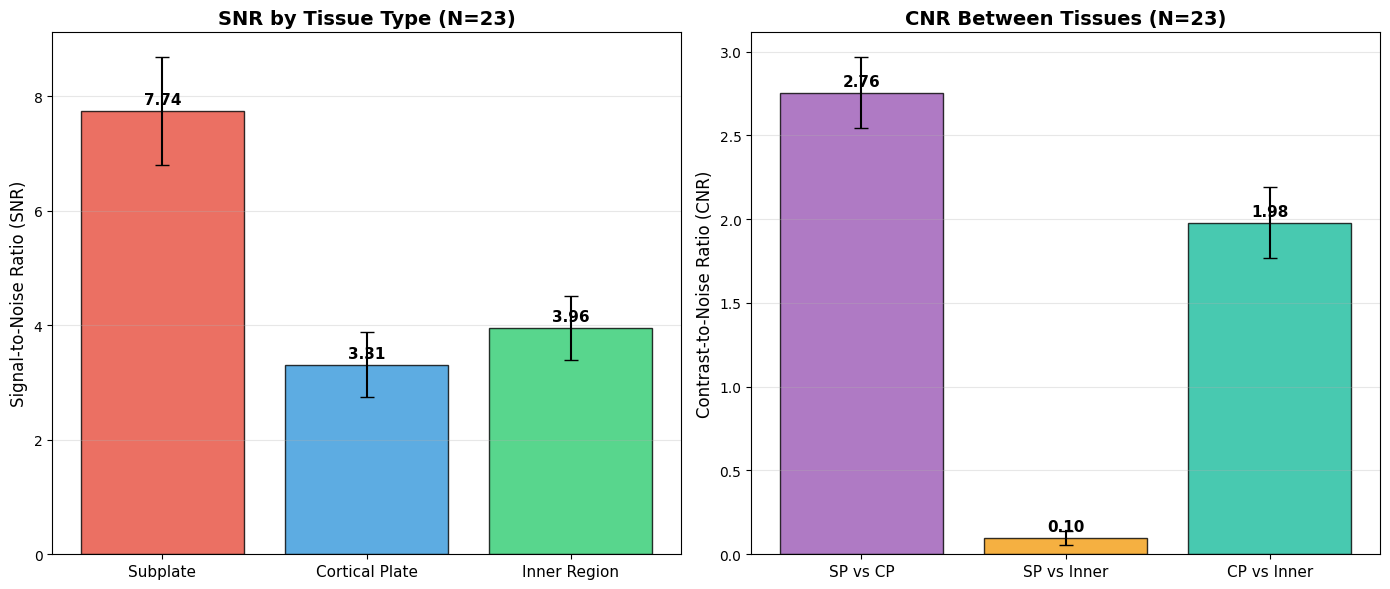

In [10]:
def plot_snr_cnr_summary(quality_df):
    """Summary bar plot of SNR and CNR metrics."""
    if len(quality_df) == 0:
        print("No image quality data available yet.")
        return None

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # SNR plot
    snr_metrics = ["snr_subplate", "snr_cortical_plate", "snr_inner"]
    snr_labels = ["Subplate", "Cortical Plate", "Inner Region"]
    snr_means = [quality_df[m].mean() for m in snr_metrics]
    snr_stds = [quality_df[m].std() for m in snr_metrics]

    x1 = np.arange(len(snr_labels))
    bars1 = ax1.bar(
        x1,
        snr_means,
        yerr=snr_stds if len(quality_df) > 1 else None,
        capsize=5,
        color=["#e74c3c", "#3498db", "#2ecc71"],
        edgecolor="black",
        alpha=0.8,
    )

    ax1.set_xticks(x1)
    ax1.set_xticklabels(snr_labels, fontsize=11)
    ax1.set_ylabel("Signal-to-Noise Ratio (SNR)", fontsize=12)
    ax1.set_title(
        f"SNR by Tissue Type (N={len(quality_df)})", fontsize=14, fontweight="bold"
    )
    ax1.grid(True, alpha=0.3, axis="y")

    for bar, mean in zip(bars1, snr_means):
        ax1.annotate(
            f"{mean:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

    # CNR plot
    cnr_metrics = ["cnr_sp_cp", "cnr_sp_inner", "cnr_cp_inner"]
    cnr_labels = ["SP vs CP", "SP vs Inner", "CP vs Inner"]
    cnr_means = [quality_df[m].mean() for m in cnr_metrics]
    cnr_stds = [quality_df[m].std() for m in cnr_metrics]

    x2 = np.arange(len(cnr_labels))
    bars2 = ax2.bar(
        x2,
        cnr_means,
        yerr=cnr_stds if len(quality_df) > 1 else None,
        capsize=5,
        color=["#9b59b6", "#f39c12", "#1abc9c"],
        edgecolor="black",
        alpha=0.8,
    )

    ax2.set_xticks(x2)
    ax2.set_xticklabels(cnr_labels, fontsize=11)
    ax2.set_ylabel("Contrast-to-Noise Ratio (CNR)", fontsize=12)
    ax2.set_title(
        f"CNR Between Tissues (N={len(quality_df)})", fontsize=14, fontweight="bold"
    )
    ax2.grid(True, alpha=0.3, axis="y")

    for bar, mean in zip(bars2, cnr_means):
        ax2.annotate(
            f"{mean:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

    plt.tight_layout()
    return fig


fig = plot_snr_cnr_summary(quality_df)
if fig:
    plt.show()

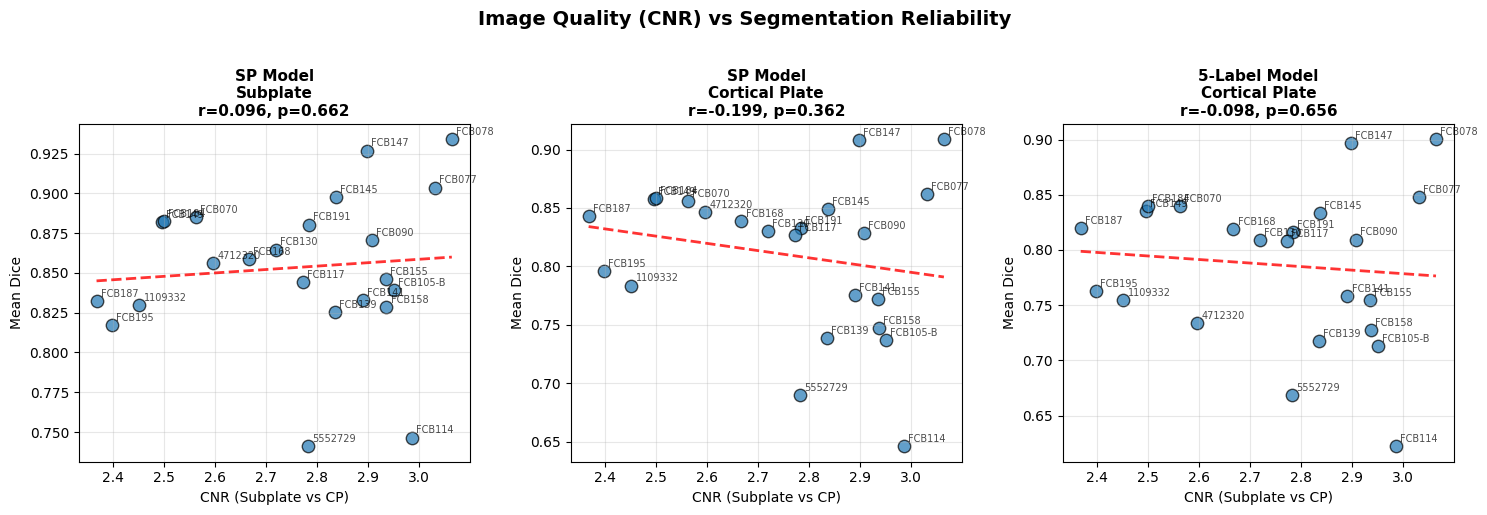

In [11]:
def plot_quality_reliability_correlation(quality_df, reliability_df):
    """Scatter plots showing correlation between image quality and reliability."""
    if len(quality_df) < 3:
        print(
            f"Need at least 3 subjects for correlation analysis. Currently have {len(quality_df)}."
        )
        return None

    # Compute mean dice per subject per model
    reliability_summary = (
        reliability_df.groupby(["subject_id", "model"])["dice"].mean().reset_index()
    )

    # Merge with quality data
    merged = quality_df.merge(reliability_summary, on="subject_id", how="inner")

    if len(merged) < 3:
        print("Not enough matched subjects for correlation.")
        return None

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]
    quality_metric = "cnr_sp_cp"

    for ax, model in zip(axes, models):
        model_data = merged[merged["model"] == model]

        if len(model_data) < 3:
            ax.text(
                0.5,
                0.5,
                f"Insufficient data\n(n={len(model_data)})",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(model.replace(" - ", "\n"), fontsize=11, fontweight="bold")
            continue

        x = model_data[quality_metric]
        y = model_data["dice"]

        ax.scatter(x, y, s=80, alpha=0.7, edgecolors="black")

        # Add subject labels
        for _, row in model_data.iterrows():
            ax.annotate(
                str(row["subject_id"])[:8],
                (row[quality_metric], row["dice"]),
                fontsize=7,
                alpha=0.7,
                xytext=(3, 3),
                textcoords="offset points",
            )

        # Correlation
        r, p = stats.pearsonr(x, y)

        # Regression line
        z = np.polyfit(x, y, 1)
        p_line = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p_line(x_line), "r--", alpha=0.8, linewidth=2)

        ax.set_xlabel("CNR (Subplate vs CP)", fontsize=10)
        ax.set_ylabel("Mean Dice", fontsize=10)
        ax.set_title(
            f'{model.replace(" - ", chr(10))}\nr={r:.3f}, p={p:.3f}',
            fontsize=11,
            fontweight="bold",
        )
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        "Image Quality (CNR) vs Segmentation Reliability",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    return fig


fig = plot_quality_reliability_correlation(quality_df, reliability_df)
if fig:
    plt.show()

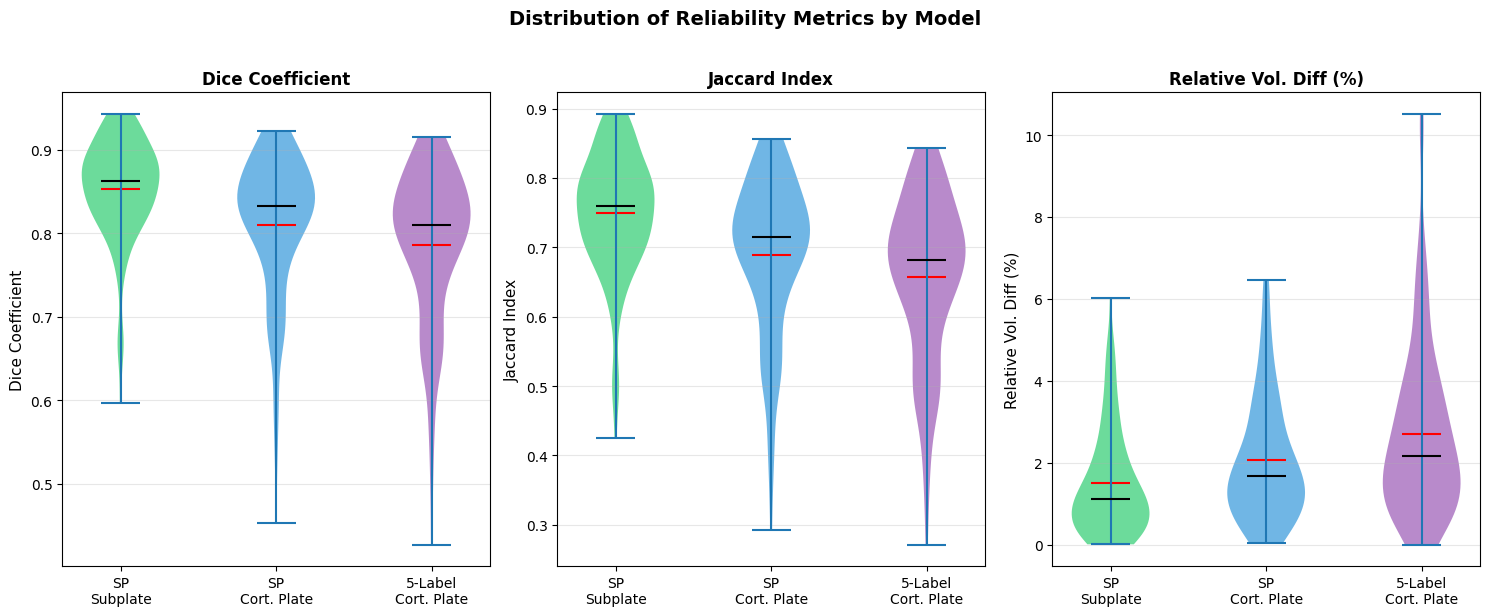

In [12]:
def plot_violin_all_metrics(df):
    """Violin plots showing distribution of all metrics by model."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]
    model_labels = ["SP\nSubplate", "SP\nCort. Plate", "5-Label\nCort. Plate"]
    metrics = ["dice", "jaccard", "relative_diff"]
    titles = ["Dice Coefficient", "Jaccard Index", "Relative Vol. Diff (%)"]
    colors = ["#2ecc71", "#3498db", "#9b59b6"]

    for ax, metric, title in zip(axes, metrics, titles):
        data = [df[df["model"] == m][metric].values for m in models]

        parts = ax.violinplot(
            data, positions=range(1, len(models) + 1), showmeans=True, showmedians=True
        )

        for i, pc in enumerate(parts["bodies"]):
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.7)

        parts["cmeans"].set_color("red")
        parts["cmedians"].set_color("black")

        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(model_labels, fontsize=10)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        "Distribution of Reliability Metrics by Model",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    return fig


fig = plot_violin_all_metrics(reliability_df)
plt.show()

In [13]:
def print_final_summary(reliability_df, quality_df):
    """Print a final summary of key findings."""
    print("\n" + "=" * 80)
    print("FINAL SUMMARY REPORT")
    print("=" * 80)

    n_subjects = reliability_df["subject_id"].nunique()
    n_quality = len(quality_df)

    print(
        f"\nDataset: {n_subjects} subjects with reliability metrics, {n_quality} with quality metrics"
    )

    print("\n--- RELIABILITY RANKING (by mean Dice) ---")
    model_means = (
        reliability_df.groupby("model")["dice"].mean().sort_values(ascending=False)
    )
    for i, (model, mean_dice) in enumerate(model_means.items(), 1):
        std = reliability_df[reliability_df["model"] == model]["dice"].std()
        print(f"  {i}. {model}: {mean_dice:.4f} ± {std:.4f}")

    # Best and worst subjects
    print("\n--- SUBJECT RELIABILITY (SP Model - Subplate) ---")
    sp_data = reliability_df[reliability_df["model"] == "SP Model - Subplate"]
    subject_means = (
        sp_data.groupby("subject_id")["dice"].mean().sort_values(ascending=False)
    )

    print("  Top 3 most reliable:")
    for subj, dice in subject_means.head(3).items():
        print(f"    {subj}: {dice:.4f}")

    print("  Bottom 3 (potential issues):")
    for subj, dice in subject_means.tail(3).items():
        print(f"    {subj}: {dice:.4f}")

    # Quality metrics summary
    if n_quality > 0:
        print(f"\n--- IMAGE QUALITY METRICS (N={n_quality}) ---")
        print(f"  Mean CNR (SP vs CP): {quality_df['cnr_sp_cp'].mean():.2f}")
        print(f"  Mean SNR (Subplate): {quality_df['snr_subplate'].mean():.2f}")

    print("\n" + "=" * 80)


print_final_summary(reliability_df, quality_df)


FINAL SUMMARY REPORT

Dataset: 23 subjects with reliability metrics, 23 with quality metrics

--- RELIABILITY RANKING (by mean Dice) ---
  1. SP Model - Subplate: 0.8533 ± 0.0621
  2. SP Model - Cortical Plate: 0.8101 ± 0.0869
  3. 5-Label Model - Cortical Plate: 0.7864 ± 0.0932

--- SUBJECT RELIABILITY (SP Model - Subplate) ---
  Top 3 most reliable:
    FCB078: 0.9339
    FCB147: 0.9269
    FCB077: 0.9037
  Bottom 3 (potential issues):
    FCB195: 0.8172
    FCB114: 0.7465
    5552729: 0.7410

--- IMAGE QUALITY METRICS (N=23) ---
  Mean CNR (SP vs CP): 2.76
  Mean SNR (Subplate): 7.74

